In [1]:
import torch #for creating tensors
import torch.nn as nn #making weights and biases tensors part of a NN
import torch.nn.functional as F #gives activation functions
from torch.optim import SGD #stochastic gradient descent to fit NN to the data


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## create class containing weights and biases & for running the data through (forward) the NN

With PyTorch, creating a new Neural Network means creatinga. new class! The custom **BasicNN** will inherit from PyTorch's class called **Module**.

In [3]:
class BasicNN(nn.Module):
    # 1 create initalization method & call initialization method from the parent class nn.Module
    def __init__(self):
        super().__init__() 
        # 2 create & initialize weights and biases in our NN (from quest's example that are alredy set)
        # make sure to use nn.Parameters and torch.tensors to ensure acceleratec arithmetic & automatic differentiation that it provides
        # w00 doesn't need to be optimized by SGD, that's why requires_grad is set to False
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad = False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad = False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad = False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad = False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad = False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad = False)

        self.final_bias = nn.Parameter(torch.tensor(-16.), requires_grad = False)
        #created parameters for each weight & bias

    #3 now the parameters need to be connected to the input, activation functions and ultimately the output = FORWARD PASS
    # takes input value and calculate the output value with weights, biases and activation functions (here relu() )
    def forward(self, input):
        #connect input to the activation function on top
        input_to_top_relu = input * self.w00 + self.b00
        #pass input to the top relu activation function
        top_relu_output = F.relu(input_to_top_relu)
        #scale relu output by the w01
        scaled_top_relu_output = top_relu_output * self.w01

        #likewise for the bottom
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)
        return output

Let's test the BasicNN with checking the squiggle we already know from teh example

In [4]:
input_doses = torch.linspace(start = 0, end = 1, steps = 11)
input_doses

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

In [5]:
model = BasicNN() #model is a standard variable name used when coding in PyTorch

In [6]:
output_values = model(input_doses) #by default calls the forward method

In [7]:
output_values

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0100, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000])

Text(0, 0.5, 'Effectiveness')

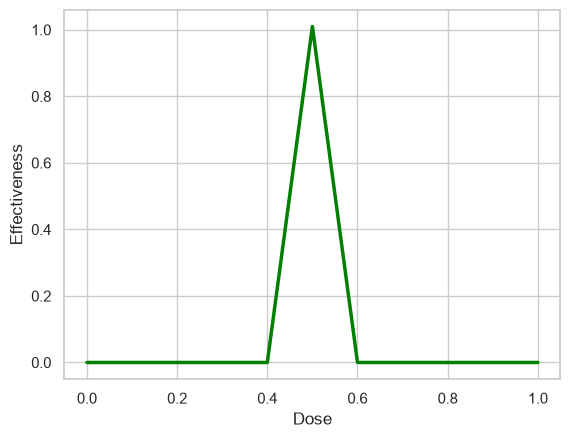

In [8]:
sns.set_theme(style = "whitegrid")
sns.lineplot(x = input_doses, #type:ignore
             y = output_values, 
             color = "green",
             linewidth = 2.5)
plt.xlabel("Dose")
plt.ylabel("Effectiveness")

The graph for BasicNN shows effectiveness = 1 when the dose = 0.5 [correct].

In [9]:
class BasicNN_train(nn.Module):
    # 1 create initalization method & call initialization method from the parent class nn.Module
    def __init__(self):
        super().__init__() 
        # 2 create & initialize weights and biases in our NN (from quest's example that are alredy set)
        # make sure to use nn.Parameters and torch.tensors to ensure acceleratec arithmetic & automatic differentiation that it provides
        # w00 doesn't need to be optimized by SGD, that's why requires_grad is set to False
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad = False)
        self.b00 = nn.Parameter(torch.tensor(-0.85), requires_grad = False)
        self.w01 = nn.Parameter(torch.tensor(-40.8), requires_grad = False)

        self.w10 = nn.Parameter(torch.tensor(12.6), requires_grad = False)
        self.b10 = nn.Parameter(torch.tensor(0.0), requires_grad = False)
        self.w11 = nn.Parameter(torch.tensor(2.7), requires_grad = False)

        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad = True) #let's optimize this parameter!!
        #created parameters for each weight & bias

    #3 now the parameters need to be connected to the input, activation functions and ultimately the output = FORWARD PASS
    # takes input value and calculate the output value with weights, biases and activation functions (here relu() )
    def forward(self, input):
        #connect input to the activation function on top
        input_to_top_relu = input * self.w00 + self.b00
        #pass input to the top relu activation function
        top_relu_output = F.relu(input_to_top_relu)
        #scale relu output by the w01
        scaled_top_relu_output = top_relu_output * self.w01

        #likewise for the bottom
        input_to_bottom_relu = input * self.w10 + self.b10
        bottom_relu_output = F.relu(input_to_bottom_relu)
        scaled_bottom_relu_output = bottom_relu_output * self.w11

        input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
        output = F.relu(input_to_final_relu)
        return output

In [10]:
model = BasicNN_train()
output_values = model(input_doses)

In [11]:
output_values

tensor([ 0.0000,  3.4020,  6.8040, 10.2060, 13.6080, 17.0100, 13.4760,  9.9420,
         6.4080,  2.8740,  0.0000], grad_fn=<ReluBackward0>)

Text(0, 0.5, 'Effectiveness')

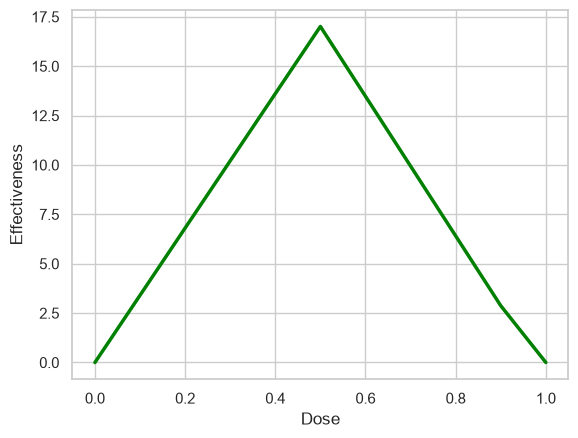

In [12]:
sns.set_theme(style = "whitegrid")
sns.lineplot(
    x=input_doses, #type:ignore
    y=output_values.detach(), #seaborn doesn't know what to do with the gradent so it needs to be stripped off with detach
    color="green",
    linewidth=2.5
)
plt.xlabel("Dose")
plt.ylabel("Effectiveness")

The graph for untrained BasicNN_train shows effectiveness = 17 when dose = 0.5 [too high, incorrect]

In [13]:
inputs = torch.tensor([0., 0.5, 1.])
labels = torch.tensor([0., 1., 0.]) #observed output values

## optimize the NN with back propagation using SGD as optimizer (only estimating and optimizing self.final_bias)

The Learning Rate for SGD here was chosen arbitrarily. Generally speaking, figuring out a good LR isn't easy and it would be nice if there was a tool that could find a GOOD lr not by a rule of thum of the engineer. Also the code for training is now intuitive, but it would be nice to have a wrapper. Lastly, it would benefit to accelereate learning with GPU and not it is running on CPU.

In [14]:
optimizer = SGD(model.parameters(), lr = 0.1) #for final_bias optimization
# the model.parameters() input to the optimizer menas that this will estimate all parameters for parameters with set required_grad = True!

In [15]:
print("Final bias, before optimization (as it was initialized): " + str(model.final_bias.data) + "\n")

Final bias, before optimization (as it was initialized): tensor(0.)



In [16]:
for epoch in range(100):
    total_loss = 0 #here SSR

    for iteration in range(len(inputs)):
        input_i = inputs[iteration]
        label_i = labels[iteration]

        output_i = model(input_i)

        loss = (output_i - label_i) ** 2 #SR, but can also be absolute value loss, MSELoss() or CrossEntropyLoss(), this loss is brand new
        #loss has access to the derivatives in the model!
        loss.backward() #calculate the derivative of the loss function with respect to the parameters to be optimized (here only final_bias), it ADDS to the previos derivative !!!, it accumulates the loss derivatives each time it goeas through the nested loop
        total_loss += float(loss.detach()) #how well the model fits all of the data, we need to add it because it doesn't accumulate itself

    if (total_loss < 0.0001):
        print("Num steps: " + str(epoch))
        break

    optimizer.step() #if total_loss is not small, then we take a small step towards better value for final_bias using optimizer.step()
    #optimizer.step() also has access to teh derivatives stored in model and can use them to step in teh correct direction
    optimizer.zero_grad() #zero out the derivatives that we're storing in model, otherwise it will accumulate in the loss for epochs

    print("Step: " + str(epoch) + " Final Bias: " + str(model.final_bias.data) + "\n")

print("Final bias, after optimization: " + str(model.final_bias.data) + "\n")

Step: 0 Final Bias: tensor(-3.2020)

Step: 1 Final Bias: tensor(-5.7636)

Step: 2 Final Bias: tensor(-7.8129)

Step: 3 Final Bias: tensor(-9.4523)

Step: 4 Final Bias: tensor(-10.7638)

Step: 5 Final Bias: tensor(-11.8131)

Step: 6 Final Bias: tensor(-12.6525)

Step: 7 Final Bias: tensor(-13.3240)

Step: 8 Final Bias: tensor(-13.8612)

Step: 9 Final Bias: tensor(-14.2909)

Step: 10 Final Bias: tensor(-14.6348)

Step: 11 Final Bias: tensor(-14.9098)

Step: 12 Final Bias: tensor(-15.1298)

Step: 13 Final Bias: tensor(-15.3059)

Step: 14 Final Bias: tensor(-15.4467)

Step: 15 Final Bias: tensor(-15.5594)

Step: 16 Final Bias: tensor(-15.6495)

Step: 17 Final Bias: tensor(-15.7216)

Step: 18 Final Bias: tensor(-15.7793)

Step: 19 Final Bias: tensor(-15.8254)

Step: 20 Final Bias: tensor(-15.8623)

Step: 21 Final Bias: tensor(-15.8919)

Step: 22 Final Bias: tensor(-15.9155)

Step: 23 Final Bias: tensor(-15.9344)

Step: 24 Final Bias: tensor(-15.9495)

Step: 25 Final Bias: tensor(-15.9616)



In [17]:
output_values = model(input_doses)

Text(0, 0.5, 'Effectiveness')

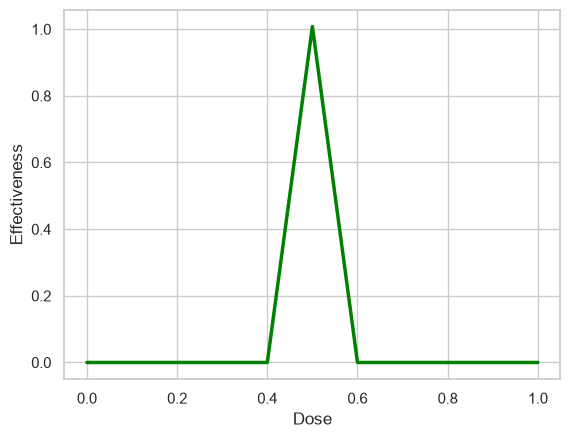

In [18]:
sns.set_theme(style = "whitegrid")
sns.lineplot(
    x=input_doses, #type:ignore
    y=output_values.detach(), #seaborn doesn't know what to do with the gradent so it needs to be stripped off with detach
    color="green",
    linewidth=2.5
)
plt.xlabel("Dose")
plt.ylabel("Effectiveness")